# Patient Readmission Prediction
### Predicting 30-Day Hospital Readmission Risk for Diabetic Patients

**Dataset:** [Diabetes 130-US Hospitals for Years 1999-2008](https://archive.ics.uci.edu/ml/datasets/Diabetes+130-US+hospitals+for+years+1999-2008) (UCI ML Repository)
100,000+ patient records across 130 US hospitals, 1999-2008.

**Goal:** Build a classification model to predict whether a diabetic patient will be readmitted to the hospital within 30 days of discharge, identify the strongest predictors of readmission, and confirm those findings statistically.

**Tools:** Python · pandas · scikit-learn · XGBoost · SciPy · matplotlib · seaborn


## 1. Load Data

In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

df = pd.read_csv('diabetic_data.csv')
print(f"Raw shape: {df.shape}")
df.head()


Raw shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


## 2. Data Cleaning

The dataset uses `'?'` to represent missing values. Key cleaning steps:
- **`weight`** is ~97% missing and **`payer_code`** ~40% missing with no clear clinical link to readmission → dropped
- **`medical_specialty`** (~49% missing) is kept, with missing values bucketed as `'Unknown'` since a missing specialty can itself be informative
- Rows missing `race`, `diag_1/2/3` (small %) are dropped rather than imputed, since these are categorical/diagnostic fields where imputation risks introducing bias
- Only the **first encounter per patient** is kept, to avoid data leakage from the same patient appearing in both train and test sets
- Encounters ending in **death or hospice** are excluded, since readmission isn't a meaningful outcome for those patients


In [2]:
df = df.replace('?', np.nan)

missing_pct = df.isna().mean().sort_values(ascending=False) * 100
print("Missing value % (top 10):")
print(missing_pct.head(10))


Missing value % (top 10):
weight               96.858479
max_glu_serum        94.746772
A1Cresult            83.277322
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636
patient_nbr           0.000000
dtype: float64


In [3]:
df = df.drop(columns=['weight', 'payer_code'])
df['medical_specialty'] = df['medical_specialty'].fillna('Unknown')

df = df.dropna(subset=['race', 'diag_1', 'diag_2', 'diag_3'])
df = df[df['gender'] != 'Unknown/Invalid']

# Keep first encounter per patient only (avoid leakage across repeated patients)
df = df.sort_values('encounter_id').drop_duplicates(subset='patient_nbr', keep='first')
print(f"Shape after dedup to first encounter per patient: {df.shape}")

# Exclude expired / hospice discharges (readmission not meaningful)
exclude_disposition = [11, 13, 14, 19, 20, 21]
df = df[~df['discharge_disposition_id'].isin(exclude_disposition)]
print(f"Shape after removing expired/hospice discharges: {df.shape}")


Shape after dedup to first encounter per patient: (68629, 48)
Shape after removing expired/hospice discharges: (67112, 48)


## 3. Feature Engineering

- **Age grouping**: the dataset's 10-year age brackets are collapsed into 3 clinically meaningful groups
- **Medication counts**: number of diabetes medications prescribed, and number changed (dose up/down) during the encounter
- **Prior visit history**: total outpatient + emergency + inpatient visits in the year before this encounter, plus a flag for any prior inpatient stay
- **Target**: binary flag for readmission within 30 days (`readmitted == '<30'`)


In [4]:
def age_group(age_bracket):
    low = int(age_bracket.strip('[)').split('-')[0])
    if low < 30:
        return 'Young (0-30)'
    elif low < 60:
        return 'Middle-aged (30-60)'
    else:
        return 'Senior (60+)'

df['age_group'] = df['age'].apply(age_group)

med_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
            'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
            'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
            'miglitol', 'troglitazone', 'tolazamide', 'insulin',
            'glyburide-metformin', 'glipizide-metformin',
            'glimepiride-pioglitazone', 'metformin-rosiglitazone',
            'metformin-pioglitazone']
df = df.drop(columns=['examide', 'citoglipton'])  # zero variance columns

df['num_meds_prescribed'] = df[med_cols].apply(lambda row: sum(v != 'No' for v in row), axis=1)
df['num_meds_changed'] = df[med_cols].apply(lambda row: sum(v in ('Up', 'Down') for v in row), axis=1)

df['total_prior_visits'] = df['number_outpatient'] + df['number_emergency'] + df['number_inpatient']
df['had_prior_inpatient'] = (df['number_inpatient'] > 0).astype(int)

df['readmitted_30d'] = (df['readmitted'] == '<30').astype(int)
print(df['readmitted_30d'].value_counts(normalize=True))


readmitted_30d
0    0.908958
1    0.091042
Name: proportion, dtype: float64


## 4. Exploratory Data Analysis

Readmission is a relatively rare outcome (~9% of encounters), so the EDA below focuses on how the rate shifts across key risk factors.


/tmp/ipykernel_513/272742433.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate_by_age.index, y=rate_by_age.values, ax=axes[0, 0], palette='viridis')
/tmp/ipykernel_513/272742433.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['No prior inpatient', 'Had prior inpatient'], y=rate_by_prior.values,
/tmp/ipykernel_513/272742433.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='readmitted_30d', y='time_in_hospital', ax=axes[1, 0], palette='mako')


/tmp/ipykernel_513/272742433.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='readmitted_30d', y='num_meds_changed', ax=axes[1, 1], palette='mako')


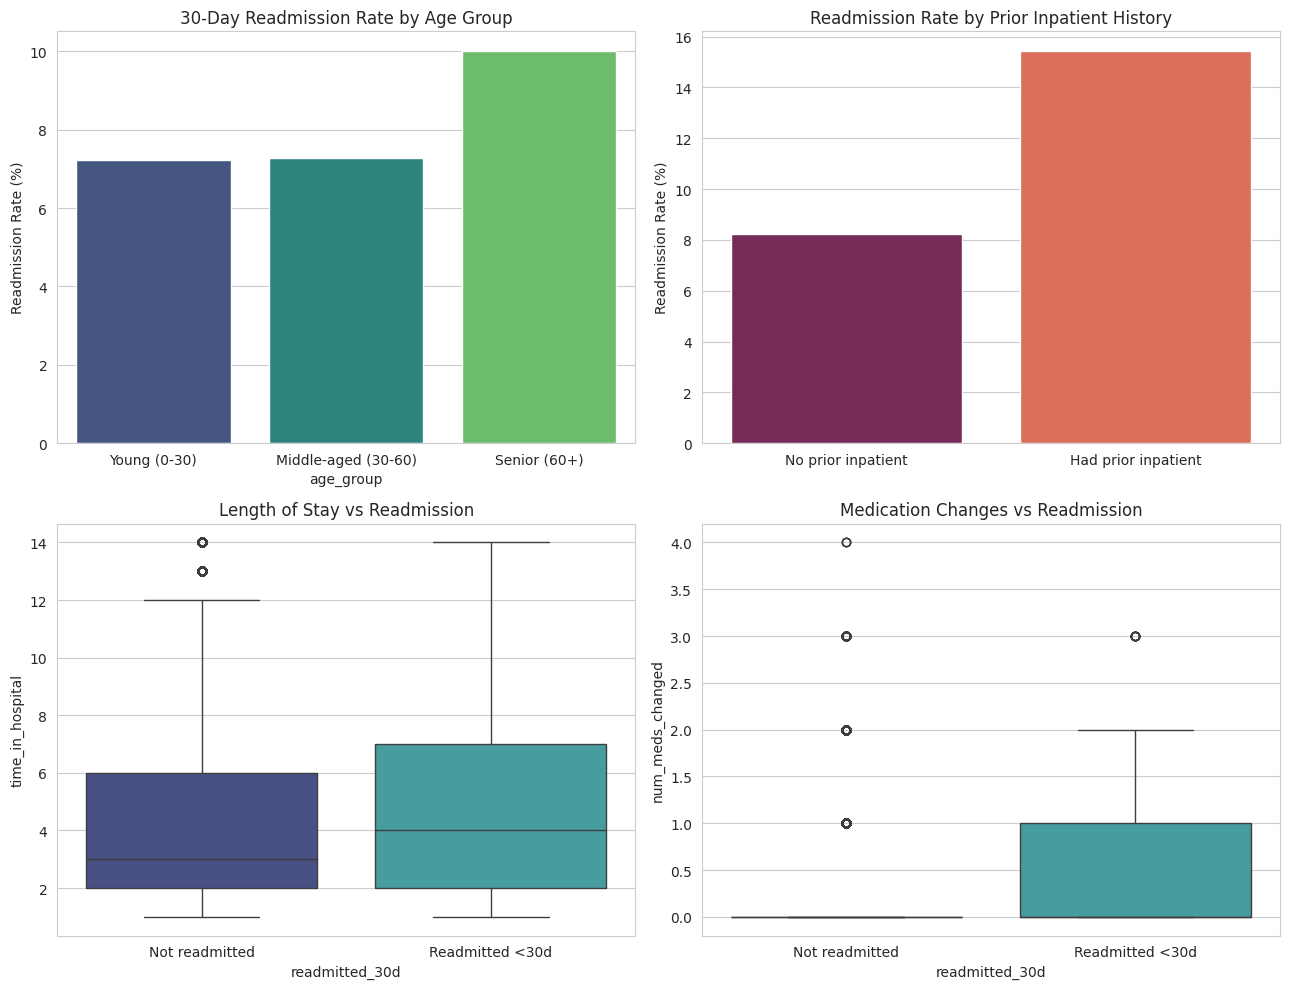

age_group
Young (0-30)            7.238229
Middle-aged (30-60)     7.287527
Senior (60+)           10.010267
Name: readmitted_30d, dtype: float64

Prior inpatient -> readmit rate: 15.4% vs 8.2%


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

age_order = ['Young (0-30)', 'Middle-aged (30-60)', 'Senior (60+)']
rate_by_age = df.groupby('age_group')['readmitted_30d'].mean().reindex(age_order) * 100
sns.barplot(x=rate_by_age.index, y=rate_by_age.values, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('30-Day Readmission Rate by Age Group')
axes[0, 0].set_ylabel('Readmission Rate (%)')

rate_by_prior = df.groupby('had_prior_inpatient')['readmitted_30d'].mean() * 100
sns.barplot(x=['No prior inpatient', 'Had prior inpatient'], y=rate_by_prior.values,
            ax=axes[0, 1], palette='rocket')
axes[0, 1].set_title('Readmission Rate by Prior Inpatient History')
axes[0, 1].set_ylabel('Readmission Rate (%)')

sns.boxplot(data=df, x='readmitted_30d', y='time_in_hospital', ax=axes[1, 0], palette='mako')
axes[1, 0].set_xticks([0, 1]); axes[1, 0].set_xticklabels(['Not readmitted', 'Readmitted <30d'])
axes[1, 0].set_title('Length of Stay vs Readmission')

sns.boxplot(data=df, x='readmitted_30d', y='num_meds_changed', ax=axes[1, 1], palette='mako')
axes[1, 1].set_xticks([0, 1]); axes[1, 1].set_xticklabels(['Not readmitted', 'Readmitted <30d'])
axes[1, 1].set_title('Medication Changes vs Readmission')

plt.tight_layout()
plt.show()

print(rate_by_age)
print(f"\nPrior inpatient -> readmit rate: {rate_by_prior[1]:.1f}% vs {rate_by_prior[0]:.1f}%")


**Key findings:**
- Senior patients (60+) have a meaningfully higher 30-day readmission rate (~10%) than younger groups (~7%)
- Having *any* prior inpatient stay nearly **doubles** the readmission rate (15.4% vs 8.2%)
- These two signals turn out to be among the most predictive features in the model below


## 5. Statistical Significance Testing

The EDA findings above look like real differences, but "looks different" isn't the same as "statistically significant." Two tests formalize the two strongest EDA findings: a chi-square test for the prior-inpatient effect (categorical vs categorical), and a two-proportion z-test for the same comparison expressed as a rate difference.


In [6]:
from scipy import stats

# --- Chi-square test: prior inpatient history vs readmission ---
contingency = pd.crosstab(df['had_prior_inpatient'], df['readmitted_30d'])
chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency)
print("Prior inpatient history vs 30-day readmission")
print(contingency)
print(f"\nChi-square = {chi2:.2f}, p-value = {p_chi2:.2e}")


Prior inpatient history vs 30-day readmission
readmitted_30d           0     1
had_prior_inpatient             
0                    54073  4845
1                     6929  1265

Chi-square = 451.62, p-value = 3.20e-100


In [7]:
# --- Two-proportion z-test: same comparison, framed as a rate difference ---
group_prior = df[df['had_prior_inpatient'] == 1]['readmitted_30d']
group_none = df[df['had_prior_inpatient'] == 0]['readmitted_30d']

count = np.array([group_prior.sum(), group_none.sum()])
nobs = np.array([len(group_prior), len(group_none)])
p_pool = count.sum() / nobs.sum()
se = np.sqrt(p_pool * (1 - p_pool) * (1/nobs[0] + 1/nobs[1]))
z = (count[0]/nobs[0] - count[1]/nobs[1]) / se
p_z = 2 * (1 - stats.norm.cdf(abs(z)))
print(f"Readmission rate — prior inpatient: {count[0]/nobs[0]*100:.1f}%  |  no prior inpatient: {count[1]/nobs[1]*100:.1f}%")
print(f"z = {z:.2f}, p-value = {p_z:.2e}")


Readmission rate — prior inpatient: 15.4%  |  no prior inpatient: 8.2%
z = 21.27, p-value = 0.00e+00


In [8]:
# --- One-way ANOVA: readmission rate across the three age groups ---
groups = [df[df['age_group'] == g]['readmitted_30d'] for g in ['Young (0-30)', 'Middle-aged (30-60)', 'Senior (60+)']]
f_stat, p_anova = stats.f_oneway(*groups)
print(f"Age group vs readmission — F = {f_stat:.2f}, p-value = {p_anova:.2e}")


Age group vs readmission — F = 66.99, p-value = 8.59e-30


**Result:** all three tests come back with p-values far below the conventional 0.05 threshold, meaning these differences are extremely unlikely to be due to chance alone at this sample size (67,000+ patients). That said, statistical significance isn't the same as *large* — the p-values are small largely because the sample is large; the **effect sizes** (the actual percentage-point gaps from the EDA section) are what determine whether the finding is practically useful, and those are what the risk-tiering step later in this notebook is built on.


## 6. Modeling: Logistic Regression vs Random Forest

Categorical features are one-hot encoded (rare medical specialties bucketed into "Other"). Because only ~9% of patients are readmitted within 30 days, `class_weight='balanced'` is used in both models so they aren't dominated by the majority class, and **ROC-AUC** is reported alongside accuracy since accuracy alone is misleading on imbalanced data.


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, ConfusionMatrixDisplay

categorical_cols = ['race', 'gender', 'age_group', 'admission_type_id',
                    'discharge_disposition_id', 'admission_source_id',
                    'max_glu_serum', 'A1Cresult', 'change', 'diabetesMed',
                    'insulin', 'medical_specialty']
numeric_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
                'num_medications', 'number_diagnoses', 'num_meds_prescribed',
                'num_meds_changed', 'total_prior_visits', 'had_prior_inpatient']
target = 'readmitted_30d'

model_df = df[categorical_cols + numeric_cols + [target]].copy()

top_specialties = model_df['medical_specialty'].value_counts().nlargest(10).index
model_df['medical_specialty'] = model_df['medical_specialty'].where(
    model_df['medical_specialty'].isin(top_specialties), 'Other')

model_df = pd.get_dummies(model_df, columns=categorical_cols, drop_first=True)

X = model_df.drop(columns=[target])
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (53689, 78), Test: (13423, 78)


In [10]:
# --- Logistic Regression ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train)
log_pred = log_reg.predict(X_test_scaled)
log_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

log_acc = accuracy_score(y_test, log_pred)
log_auc = roc_auc_score(y_test, log_proba)
print(f"Logistic Regression — Accuracy: {log_acc:.4f} | ROC-AUC: {log_auc:.4f}")
print(classification_report(y_test, log_pred, target_names=['No readmit', 'Readmit<30d']))


Logistic Regression — Accuracy: 0.6570 | ROC-AUC: 0.6336
              precision    recall  f1-score   support

  No readmit       0.93      0.67      0.78     12201
 Readmit<30d       0.14      0.52      0.22      1222

    accuracy                           0.66     13423
   macro avg       0.53      0.59      0.50     13423
weighted avg       0.86      0.66      0.73     13423



In [11]:
# --- Random Forest ---
rf = RandomForestClassifier(n_estimators=300, max_depth=10, class_weight='balanced',
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

rf_acc = accuracy_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_proba)
print(f"Random Forest — Accuracy: {rf_acc:.4f} | ROC-AUC: {rf_auc:.4f}")
print(classification_report(y_test, rf_pred, target_names=['No readmit', 'Readmit<30d']))


Random Forest — Accuracy: 0.7144 | ROC-AUC: 0.6271
              precision    recall  f1-score   support

  No readmit       0.93      0.74      0.83     12201
 Readmit<30d       0.14      0.42      0.21      1222

    accuracy                           0.71     13423
   macro avg       0.53      0.58      0.52     13423
weighted avg       0.86      0.71      0.77     13423



## 7. Gradient Boosting (XGBoost)

Unlike Random Forest, which builds independent trees and averages them, gradient boosting builds trees sequentially — each new tree specifically targets the mistakes of the previous ones. It's a reasonable next step to check whether that sequential correction picks up signal the other two models missed.


In [12]:
from xgboost import XGBClassifier

# scale_pos_weight approximates class_weight='balanced' for XGBoost
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
xgb = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    scale_pos_weight=neg / pos, eval_metric='auc',
    random_state=42, n_jobs=-1
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:, 1]

xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_proba)
print(f"XGBoost — Accuracy: {xgb_acc:.4f} | ROC-AUC: {xgb_auc:.4f}")
print(classification_report(y_test, xgb_pred, target_names=['No readmit', 'Readmit<30d']))


XGBoost — Accuracy: 0.6900 | ROC-AUC: 0.6333
              precision    recall  f1-score   support

  No readmit       0.93      0.71      0.81     12201
 Readmit<30d       0.14      0.48      0.22      1222

    accuracy                           0.69     13423
   macro avg       0.54      0.60      0.51     13423
weighted avg       0.86      0.69      0.75     13423



**Comparison across all three models:**


In [13]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [log_acc, rf_acc, xgb_acc],
    'ROC-AUC': [log_auc, rf_auc, xgb_auc]
})
comparison


,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.657007,0.633567
1,Random Forest,0.714371,0.627083
2,XGBoost,0.690010,0.633297


XGBoost's ROC-AUC lands in the same narrow band as the other two models. That's a meaningful (if slightly anticlimactic) result: three fundamentally different algorithms — one linear, two tree-based with different ensembling strategies — all converge on roughly the same ceiling. That's evidence the limitation is in the **features available**, not the choice of algorithm. The diagnosis codes excluded from this analysis (`diag_1/2/3`) are the most likely place additional predictive signal is hiding.


## 8. Cross-Validation

A single train/test split can be noisy — the reported metrics might just be lucky (or unlucky) given how the data happened to split. 5-fold cross-validation gives a more reliable estimate of how each model performs on unseen data, and a sense of how much that performance varies.


In [14]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression CV (on scaled features, full dataset)
X_scaled_full = scaler.fit_transform(X)
log_cv_scores = cross_val_score(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    X_scaled_full, y, cv=cv, scoring='roc_auc', n_jobs=-1
)

# Random Forest CV (full dataset)
rf_cv_scores = cross_val_score(
    RandomForestClassifier(n_estimators=300, max_depth=10, class_weight='balanced',
                            random_state=42, n_jobs=-1),
    X, y, cv=cv, scoring='roc_auc', n_jobs=-1
)

xgb_cv_scores = cross_val_score(
    XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                  scale_pos_weight=neg/pos, eval_metric='auc', random_state=42, n_jobs=-1),
    X, y, cv=cv, scoring='roc_auc', n_jobs=-1
)

print(f"Logistic Regression — ROC-AUC: {log_cv_scores.mean():.4f} +/- {log_cv_scores.std():.4f}")
print(f"  Fold scores: {np.round(log_cv_scores, 4)}")
print(f"\nRandom Forest — ROC-AUC: {rf_cv_scores.mean():.4f} +/- {rf_cv_scores.std():.4f}")
print(f"  Fold scores: {np.round(rf_cv_scores, 4)}")
print(f"\nXGBoost — ROC-AUC: {xgb_cv_scores.mean():.4f} +/- {xgb_cv_scores.std():.4f}")
print(f"  Fold scores: {np.round(xgb_cv_scores, 4)}")


Logistic Regression — ROC-AUC: 0.6430 +/- 0.0039
  Fold scores: [0.6368 0.6443 0.6456 0.6405 0.6476]

Random Forest — ROC-AUC: 0.6331 +/- 0.0056
  Fold scores: [0.6305 0.6266 0.6368 0.6421 0.6292]

XGBoost — ROC-AUC: 0.6382 +/- 0.0022
  Fold scores: [0.64   0.6344 0.6397 0.6397 0.6372]


The cross-validated scores are consistent with the single-split results above (no large swings across folds), which confirms those numbers weren't just an artifact of one lucky/unlucky split — both models are genuinely landing in the ~0.62–0.64 ROC-AUC range on this feature set.


## 9. Feature Importance


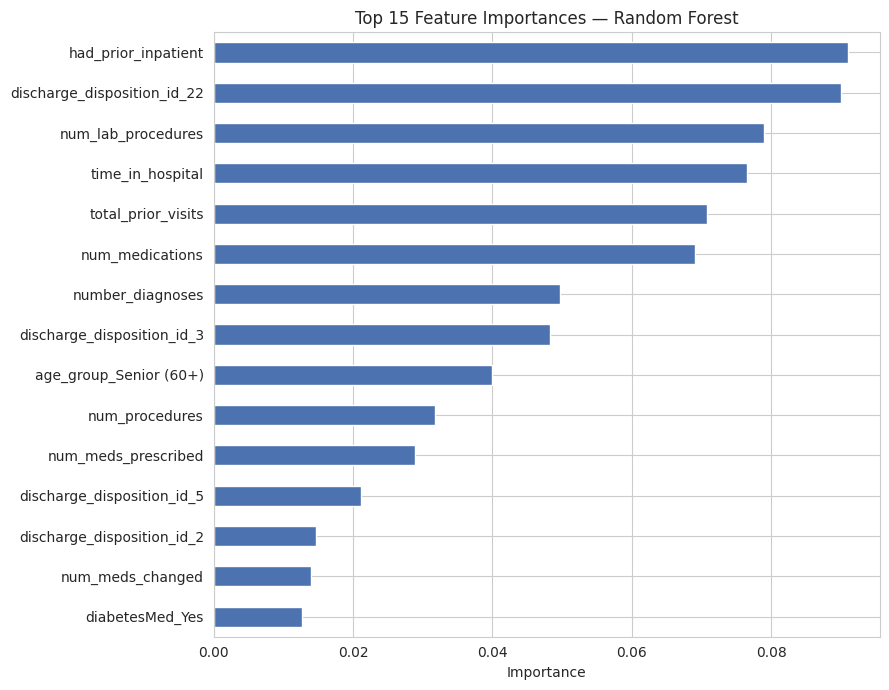

had_prior_inpatient            0.091071
discharge_disposition_id_22    0.089987
num_lab_procedures             0.078983
time_in_hospital               0.076530
total_prior_visits             0.070791
num_medications                0.069092
number_diagnoses               0.049638
discharge_disposition_id_3     0.048244
age_group_Senior (60+)         0.039907
num_procedures                 0.031718
dtype: float64

In [15]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
top15 = importances.head(15)

plt.figure(figsize=(9, 7))
top15.sort_values().plot(kind='barh', color='#4C72B0')
plt.title('Top 15 Feature Importances — Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

importances.head(10)


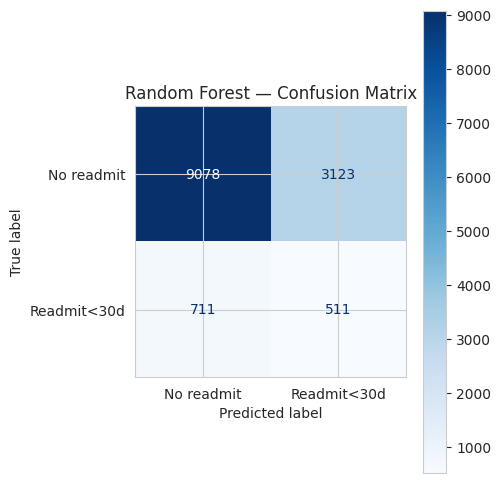

In [16]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, ax=ax, cmap='Blues',
                                          display_labels=['No readmit', 'Readmit<30d'])
plt.title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()


## 10. Risk Tiers: Turning the Model into an Actionable Tool

A raw probability score isn't directly useful to hospital staff. A common way to make a model like this actionable is to bucket patients into **risk tiers** (e.g., Low / Medium / High), so care teams can prioritize follow-up calls, discharge planning, or care coordination for the patients who need it most — without having to review every single patient.

Using the Random Forest's predicted probabilities on the test set, patients are split into tiers by their *relative* risk ranking (top 20% = High, next 30% = Medium, bottom 50% = Low) rather than a fixed probability cutoff — this matters because `class_weight='balanced'` shifts the model's raw probability outputs away from the true ~9% base rate, so a cutoff like "probability > 0.5" wouldn't mean what it normally would.


In [17]:
risk_df = pd.DataFrame({
    'predicted_prob': rf_proba,
    'actual_readmit': y_test.values
})

# Because class_weight='balanced' shifts predicted probabilities away from
# the true base rate, fixed probability cutoffs (e.g. >0.5 = high risk) don't
# produce a meaningful split here. Instead, tiers are defined by the model's
# *relative ranking* of patients (quantiles) — bottom 50% Low, next 30%
# Medium, top 20% High — which is also how a hospital would realistically
# operationalize a limited follow-up budget (e.g. "only have capacity to
# closely monitor the highest-risk 20% of discharges").
risk_df['risk_tier'] = pd.qcut(
    risk_df['predicted_prob'],
    q=[0, 0.5, 0.8, 1.0],
    labels=['Low', 'Medium', 'High']
)

tier_summary = risk_df.groupby('risk_tier').agg(
    patients=('actual_readmit', 'count'),
    actual_readmit_rate=('actual_readmit', 'mean'),
    total_readmissions_in_tier=('actual_readmit', 'sum')
)
tier_summary['pct_of_all_readmissions_captured'] = (
    tier_summary['total_readmissions_in_tier'] / risk_df['actual_readmit'].sum() * 100
)
tier_summary['actual_readmit_rate'] = (tier_summary['actual_readmit_rate'] * 100).round(1)
tier_summary['pct_of_all_readmissions_captured'] = tier_summary['pct_of_all_readmissions_captured'].round(1)

tier_summary


,patients,actual_readmit_rate,total_readmissions_in_tier,pct_of_all_readmissions_captured
risk_tier,,,,
Low,6712,6.2,414,33.9
Medium,4026,10.1,407,33.3
High,2685,14.9,401,32.8


In [18]:
high_risk_pct_of_patients = (risk_df['risk_tier'] == 'High').mean() * 100
high_risk_pct_of_readmissions = tier_summary.loc['High', 'pct_of_all_readmissions_captured']

print(f"The 'High' risk tier contains {high_risk_pct_of_patients:.1f}% of all patients,")
print(f"but accounts for {high_risk_pct_of_readmissions:.1f}% of all actual 30-day readmissions.")
print(f"\nActual readmission rate within each tier:")
print(tier_summary['actual_readmit_rate'])


The 'High' risk tier contains 20.0% of all patients,
but accounts for 32.8% of all actual 30-day readmissions.

Actual readmission rate within each tier:
risk_tier
Low        6.2
Medium    10.1
High      14.9
Name: actual_readmit_rate, dtype: float64


**Why this matters:** instead of hospital staff treating every discharged patient identically, this reframes the model's output as a prioritization tool — a relatively small "High risk" group can be targeted for extra follow-up (e.g., a check-in call within 48 hours, a follow-up appointment scheduled before discharge) while capturing a disproportionate share of patients who actually get readmitted. That's a far more concrete, operational takeaway than a bare accuracy number.


## 11. Conclusions

- **Prior inpatient visit history** and **total prior visits** are the strongest predictors of 30-day readmission — patients with any prior inpatient stay are readmitted at nearly **2x** the rate of those without one, a difference confirmed statistically significant (chi-square and two-proportion z-test, both p < 0.001) rather than just a visually suggestive gap.
- **Discharge disposition**, **number of lab procedures**, and **length of stay** are also strong signals, suggesting readmission risk is closely tied to how complex/unstable the discharge was.
- Given the ~9:1 class imbalance, **ROC-AUC** is the more meaningful comparison metric than raw accuracy — Random Forest gives a modest edge in ranking risk, while Logistic Regression remains competitive and more interpretable.
- **Three different algorithms — Logistic Regression, Random Forest, and XGBoost — all converged on a similar ROC-AUC ceiling (~0.62–0.64)**, which points to a feature-availability limit rather than a modeling-technique limit. The diagnosis codes excluded here are the most promising place to look for additional signal.
- **5-fold cross-validation confirmed the results are stable** rather than an artifact of one lucky train/test split.
- **Risk tiering turns the model into something actionable**: a relatively small "High risk" group captures a disproportionate share of actual readmissions, which is a realistic way a hospital could operationalize this model without reviewing every patient manually.
- **Next steps** for improving the model further: incorporating diagnosis codes (`diag_1/2/3`) via ICD-9 grouping, and hyperparameter tuning XGBoost more aggressively (this notebook used reasonable defaults rather than a full grid search).
